# Subsequent Collision Differentiation: Boujibar S7

This example reads the embryo-composition table generated by `examples/Accrection/A_Embryos_Composition.ipynb` and constructs a subsequent collision event. `event_index=1` explicitly selects supplementary Eq. S7 (Boujibar).

Physical boundary: the pre-existing target core remains isolated. The entire impactor and a specified fraction of the target mantle form the equilibrating subsystem. Only this subsystem differentiates again before it is recombined with the locked reservoirs.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = None
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "accrediff").exists():
        PROJECT_ROOT = parent
        sys.path.insert(0, str(parent / "src"))
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the AccreDiff repository root.")

import accrediff as ad
pd.set_option("display.precision", 6)

## 1. Load Two Previously Differentiated Embryos

The example selects embryo 61 as the target and embryo 4755 as the impactor. Their combined mass gives $P\approx7.76$ GPa and $T\approx2208$ K, within the Boujibar pressure–temperature range documented by the module. The embryo table does not track S, so sulfur delivered by the impactor is introduced below as an explicit external parameter.

In [2]:
embryo_file = PROJECT_ROOT / "examples/Accrection/Tables/note_02_early_composition.csv"
embryos = pd.read_csv(embryo_file).set_index("i")
target_id, impactor_id = 61, 4755
if target_id not in embryos.index or impactor_id not in embryos.index:
    raise KeyError("Selected target/impactor IDs are absent from the embryo table.")

target = embryos.loc[target_id]
impactor = embryos.loc[impactor_id]
pd.DataFrame({"target": target, "impactor": impactor}).loc[
    ["m_e", "P", "T", "FeO", "NiO", "SiO2", "Fe", "Ni", "Si", "O"]
]

,target,impactor
m_e,0.035116,0.030792
P,4.305123,3.820515
T,2081.923650,2061.449803
FeO,0.032133,0.077100
NiO,0.000042,0.000109
SiO2,0.332774,0.349245
Fe,0.240282,0.181546
Ni,0.014982,0.014071
Si,0.000473,0.000075
O,0.001119,0.002267


## 2. Convert Normalized Compositions to Mass-Consistent Molar Inventories

The embryo table stores normalized molar compositions. Before mixing, the mean molar mass of each embryo is calculated and its total molar inventory is scaled by `m_e / mean_MW`. The omitted Earth-mass conversion factor is common to every component and therefore does not affect the equilibrium equations.

In [3]:
mantle_components = ["MgO", "Al2O3", "CaO", "FeO", "NiO", "SiO2"]
metal_components = ["Fe", "Ni", "Si", "O"]
components = mantle_components + metal_components

mm = ad.MolarMassCalculator()
component_MW = {
    **{name: mm.molar_mass(name) for name in mantle_components},
    **{name: ad.constants.Elements[name] for name in metal_components},
}

def embryo_molar_inventory(row):
    composition = {name: float(row[name]) for name in components}
    total_x = sum(composition.values())
    mole_fraction = {name: value / total_x for name, value in composition.items()}
    mean_MW = sum(mole_fraction[name] * component_MW[name] for name in components)
    total_moles_scaled = float(row["m_e"]) / mean_MW
    return {name: mole_fraction[name] * total_moles_scaled for name in components}

target_inventory = embryo_molar_inventory(target)
impactor_inventory = embryo_molar_inventory(impactor)

## 3. Define the Equilibrating and Locked Reservoirs

This example assumes that the entire impactor enters the equilibration region, 25% of the target mantle participates in melt equilibration, and the pre-existing target core remains fully locked. `delivered_S_fraction` is the added molar sulfur inventory relative to the sulfur-free equilibrating inventory; in a physical simulation it should be supplied by the impactor or volatile-delivery model.

In [4]:
target_mantle_equilibration_fraction = 0.25
delivered_S_fraction = 0.01

locked_target = {
    name: (1.0 - target_mantle_equilibration_fraction) * target_inventory[name]
    for name in mantle_components
}
locked_target.update({name: target_inventory[name] for name in metal_components})

equilibrating = {}
for name in components:
    target_part = (
        target_mantle_equilibration_fraction * target_inventory[name]
        if name in mantle_components else 0.0
    )
    equilibrating[name] = target_part + impactor_inventory[name]
equilibrating["S"] = delivered_S_fraction * sum(equilibrating.values())

event_mass = float(target["m_e"] + impactor["m_e"])
P = float(ad.Early_pressure(event_mass))
T = float(ad.P_to_T(P))

pd.Series({
    "event_mass_Mearth": event_mass,
    "P_GPa": P, "T_K": T,
    "target_mantle_equilibration_fraction": target_mantle_equilibration_fraction,
    "delivered_S_fraction": delivered_S_fraction,
}).to_frame("value")

,value
event_mass_Mearth,0.065908
P_GPa,7.755638
T_K,2208.237634
target_mantle_equilibration_fraction,0.250000
delivered_S_fraction,0.010000


## 4. Apply S7 to the Equilibrating Subsystem

`sulfur_params_from_composition()` receives the converted molar inventory of the equilibrating subsystem—not the raw wt% composition or the entire target. The oxygen-loss parameter is reconstructed automatically from the supplied phase-resolved composition.

In [5]:
kd_calculator = ad.SulfurKDCalculator()
KD_O = kd_calculator.get_KD("O", P, T)
params = ad.sulfur_params_from_composition(
    equilibrating, P=P, T=T, major_kd_calculator=kd_calculator,
)

driver = ad.SulfurDifferentiationEventDriver(
    sulfur_kd_calculator=kd_calculator,
    sulfur_grid_N=20, ni_grid_N=24,
)
solver = driver.make_solver_factory(event_index=1, P=P, T=T)(params)
result_object = solver.solve_x_for_KD_O(
    KD_O, tol=1e-8, max_iter=200, grid_N=80,
)
result = vars(result_object)

assert result["sulfur_model"] == "boujibar"
assert result["overall_converged"], result["failure_reason"]
assert np.isclose(result["S_met_"] + result["S_sil_"], params.S_t,
                  rtol=1e-12, atol=1e-15)

pd.Series({
    "model": result["sulfur_model"],
    "D_S_mole": result["D_S_mole"],
    "fraction_delivered_S_in_equilibrated_metal": result["S_met_"] / params.S_t,
    "KD_Ni_base": result["KD_Ni_base"],
    "KD_Ni_activity_factor": result["KD_Ni_activity_factor"],
    "KD_Ni_effective": result["KD_Ni_effective"],
    "X_Ni_ternary": result["X_Ni_ternary"],
    "overall_converged": result["overall_converged"],
}, name="subsequent_S7").to_frame()

,subsequent_S7
model,boujibar
D_S_mole,0.520323
fraction_delivered_S_in_equilibrated_metal,0.08927
KD_Ni_base,24.386742
KD_Ni_activity_factor,0.97847
KD_Ni_effective,23.861691
X_Ni_ternary,0.071017
overall_converged,True


## 5. Recombine the New Equilibrium State with the Locked Reservoirs

The locked target core is never passed to the S7 solver, so it cannot be spuriously reoxidized or release its existing elements into the mantle. The following cell recombines the reservoirs and independently audits elemental conservation.

In [6]:
equilibrated_after = {
    "MgO": params.u, "Al2O3": params.m / 2.0, "CaO": params.n,
    "FeO": result["x_"], "NiO": result["y_"], "SiO2": result["z_"],
    "Fe": result["a_"], "Ni": result["b_"], "Si": result["c_"],
    "O": result["d_"], "S_met": result["S_met_"],
    "S_sil": result["S_sil_"],
}
final_collision_product = {
    name: locked_target.get(name, 0.0) + equilibrated_after.get(name, 0.0)
    for name in components
}
final_collision_product["S_met"] = equilibrated_after["S_met"]
final_collision_product["S_sil"] = equilibrated_after["S_sil"]

input_product = {
    name: target_inventory[name] + impactor_inventory[name] for name in components
}
input_product["S"] = equilibrating["S"]

def elemental_totals(composition):
    return {
        "Fe": composition.get("Fe", 0.0) + composition.get("FeO", 0.0),
        "Ni": composition.get("Ni", 0.0) + composition.get("NiO", 0.0),
        "Si": composition.get("Si", 0.0) + composition.get("SiO2", 0.0),
        "Mg": composition.get("MgO", 0.0),
        "Al": 2.0 * composition.get("Al2O3", 0.0),
        "Ca": composition.get("CaO", 0.0),
        "S": (composition.get("S", 0.0) + composition.get("S_met", 0.0)
              + composition.get("S_sil", 0.0)),
    }

audit = pd.DataFrame({
    "before_collision_differentiation": elemental_totals(input_product),
    "after_reservoir_merge": elemental_totals(final_collision_product),
})
audit["relative_error"] = (
    audit["after_reservoir_merge"] - audit["before_collision_differentiation"]
) / audit["before_collision_differentiation"]
assert np.allclose(audit["relative_error"], 0.0, rtol=0.0, atol=1e-10)
audit

,before_collision_differentiation,after_reservoir_merge,relative_error
Fe,0.000328,0.000328,1.654515e-16
Ni,0.000018,0.000018,1.880001e-16
Si,0.000420,0.000420,0.000000e+00
Mg,0.000423,0.000423,1.280456e-16
Al,0.000035,0.000035,1.940200e-16
Ca,0.000026,0.000026,0.000000e+00
S,0.000007,0.000007,0.000000e+00


,core_metal,mantle_silicate
Mg,0.000000,100.000000
Al,0.000000,100.000000
Ca,0.000000,100.000000
Fe,79.971156,20.028844
Ni,98.995910,1.004090
Si,0.095886,99.904114
O,0.118317,99.881683
S,8.927049,91.072951


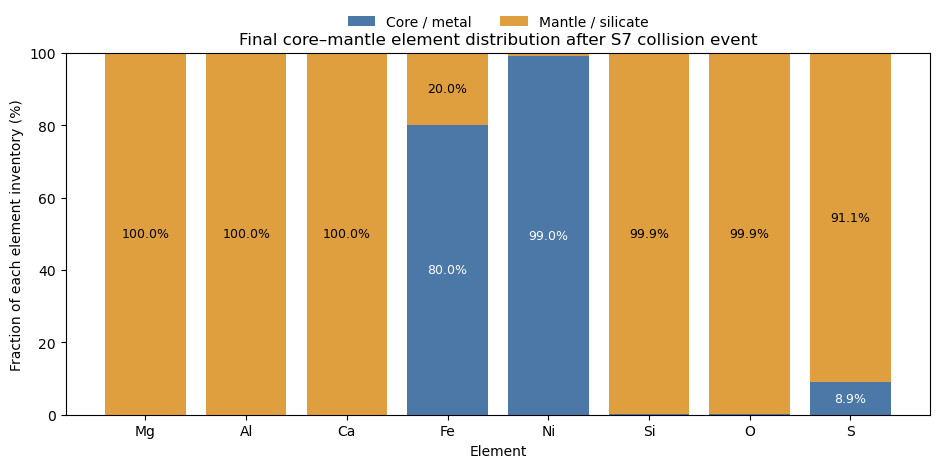

In [7]:
# Final whole-product inventories: locked target core/mantle plus the
# re-equilibrated collision subsystem. The source table contains no
# historical sulfur, so the S bars refer to sulfur delivered in this event.
element_phase_mol = pd.DataFrame({
    "core_metal": {
        "Mg": 0.0, "Al": 0.0, "Ca": 0.0,
        "Fe": final_collision_product["Fe"],
        "Ni": final_collision_product["Ni"],
        "Si": final_collision_product["Si"],
        "O": final_collision_product["O"],
        "S": final_collision_product["S_met"],
    },
    "mantle_silicate": {
        "Mg": final_collision_product["MgO"],
        "Al": 2.0 * final_collision_product["Al2O3"],
        "Ca": final_collision_product["CaO"],
        "Fe": final_collision_product["FeO"],
        "Ni": final_collision_product["NiO"],
        "Si": final_collision_product["SiO2"],
        "O": (final_collision_product["FeO"]
              + final_collision_product["NiO"]
              + 2.0 * final_collision_product["SiO2"]
              + final_collision_product["MgO"]
              + 3.0 * final_collision_product["Al2O3"]
              + final_collision_product["CaO"]),
        "S": final_collision_product["S_sil"],
    },
})
element_distribution_percent = element_phase_mol.div(
    element_phase_mol.sum(axis=1), axis=0
) * 100.0
display(element_distribution_percent)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
elements = element_distribution_percent.index
core_fraction = element_distribution_percent["core_metal"]
mantle_fraction = element_distribution_percent["mantle_silicate"]
ax.bar(elements, core_fraction, color="#4C78A8", label="Core / metal")
ax.bar(elements, mantle_fraction, bottom=core_fraction,
       color="#E09F3E", label="Mantle / silicate")
for x_position, core_value, mantle_value in zip(
    range(len(elements)), core_fraction, mantle_fraction
):
    if core_value >= 3.0:
        ax.text(x_position, core_value / 2.0, f"{core_value:.1f}%",
                ha="center", va="center", color="white", fontsize=9)
    if mantle_value >= 3.0:
        ax.text(x_position, core_value + mantle_value / 2.0,
                f"{mantle_value:.1f}%", ha="center", va="center",
                color="black", fontsize=9)
ax.set_ylabel("Fraction of each element inventory (%)")
ax.set_xlabel("Element")
ax.set_title("Final core–mantle element distribution after S7 collision event")
ax.set_ylim(0, 100)
ax.legend(frameon=False, ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, 1.14))
fig.tight_layout()
plt.show()

### Parameters to Replace When Using Physical Collision Data

- `target_id` and `impactor_id`: obtain them from the collision record.
- `target_mantle_equilibration_fraction`: obtain it from an impact-melting or metal-emulsification model.
- `delivered_S_fraction`: obtain it from the impactor sulfur inventory.
- `P, T`: obtain them from the collision product or magma-ocean conditions.
- If only part of the impactor core equilibrates, add the non-equilibrating part to the locked metal reservoir.

`overall_converged=True` indicates numerical convergence only. Model applicability and reservoir participation fractions must still be constrained by the physical model.